In [1]:
import pandas as pd
import numpy as np

# to get rid of warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Run the below line to install a lower version if gdown throws any error
! pip install gdown==4.6.0

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2


In [3]:
!gdown 1_jZRFvpjElFBGyOO-_4Cv68-n2cDbNUn

Downloading...
From: https://drive.google.com/uc?id=1_jZRFvpjElFBGyOO-_4Cv68-n2cDbNUn
To: /content/pred_data.csv
100% 247k/247k [00:00<00:00, 18.9MB/s]


In [4]:
data = pd.read_csv('pred_data.csv')

data.head()

,y,proba
0,0.0,0.281035
1,0.0,0.465152
2,0.0,0.352793
3,0.0,0.157818
4,0.0,0.276648


In [5]:
# creating predictions based on the probabilities using the isgmoid logic
data['y_pred'] = data['proba'].apply(lambda y_score: 0.0 if y_score < 0.5 else 1.0)

In [23]:
# creating predictions based on the probabilities using the isgmoid logic
data['y_pred_0.7'] = data['proba'].apply(lambda y_score: 0.0 if y_score < 0.7 else 1.0)

In [25]:
data['y_pred_0.8'] = data['proba'].apply(lambda y_score: 0.0 if y_score < 0.7 else 1.0)

In [33]:
data['y_pred_0.2'] = data['proba'].apply(lambda y_score: 0.0 if y_score < 0.2 else 1.0)

In [28]:
print(classification_report(data.y, data.y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     10000
         1.0       0.19      0.55      0.28       100

    accuracy                           0.97     10100
   macro avg       0.59      0.76      0.63     10100
weighted avg       0.99      0.97      0.98     10100



In [34]:
print(classification_report(data.y, data['y_pred_0.2']))

              precision    recall  f1-score   support

         0.0       1.00      0.25      0.40     10000
         1.0       0.01      1.00      0.03       100

    accuracy                           0.26     10100
   macro avg       0.51      0.63      0.21     10100
weighted avg       0.99      0.26      0.40     10100



In [27]:
data

,y,proba,y_pred,y_pred_0.7,y_pred_0.8
0,0.0,0.281035,0.0,0.0,0.0
1,0.0,0.465152,0.0,0.0,0.0
2,0.0,0.352793,0.0,0.0,0.0
3,0.0,0.157818,0.0,0.0,0.0
4,0.0,0.276648,0.0,0.0,0.0
...,...,...,...,...,...
10095,0.0,0.474401,0.0,0.0,0.0
10096,0.0,0.128403,0.0,0.0,0.0
10097,0.0,0.499331,0.0,0.0,0.0
10098,0.0,0.157616,0.0,0.0,0.0


In [7]:
data


,y,proba,y_pred
0,0.0,0.281035,0.0
1,0.0,0.465152,0.0
2,0.0,0.352793,0.0
3,0.0,0.157818,0.0
4,0.0,0.276648,0.0
...,...,...,...
10095,0.0,0.474401,0.0
10096,0.0,0.128403,0.0
10097,0.0,0.499331,0.0
10098,0.0,0.157616,0.0


In [8]:
# Necessary imports
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.zeros(len(data.y))

In [9]:
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

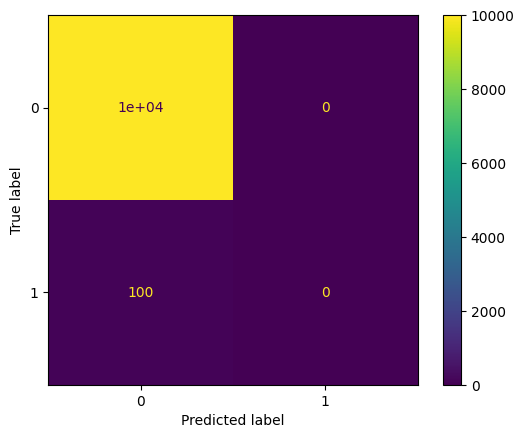

In [10]:
# predictions of a dumb model
conf_matrix = confusion_matrix(data.y, y_pred)
ConfusionMatrixDisplay(conf_matrix).plot();

In [11]:
from sklearn.metrics import precision_score

In [12]:
precision_score(data.y, y_pred)

0.0

In [13]:
precision_score(data.y, data.y_pred)

0.1870748299319728

In [14]:
from sklearn.metrics import recall_score

In [15]:
recall_score(data.y, y_pred)

0.0

In [16]:
recall_score(data.y, data.y_pred)

0.55

In [17]:
from sklearn.metrics import f1_score

In [18]:
f1_score(data.y, data.y_pred)

0.27918781725888325

## Homework Case Study

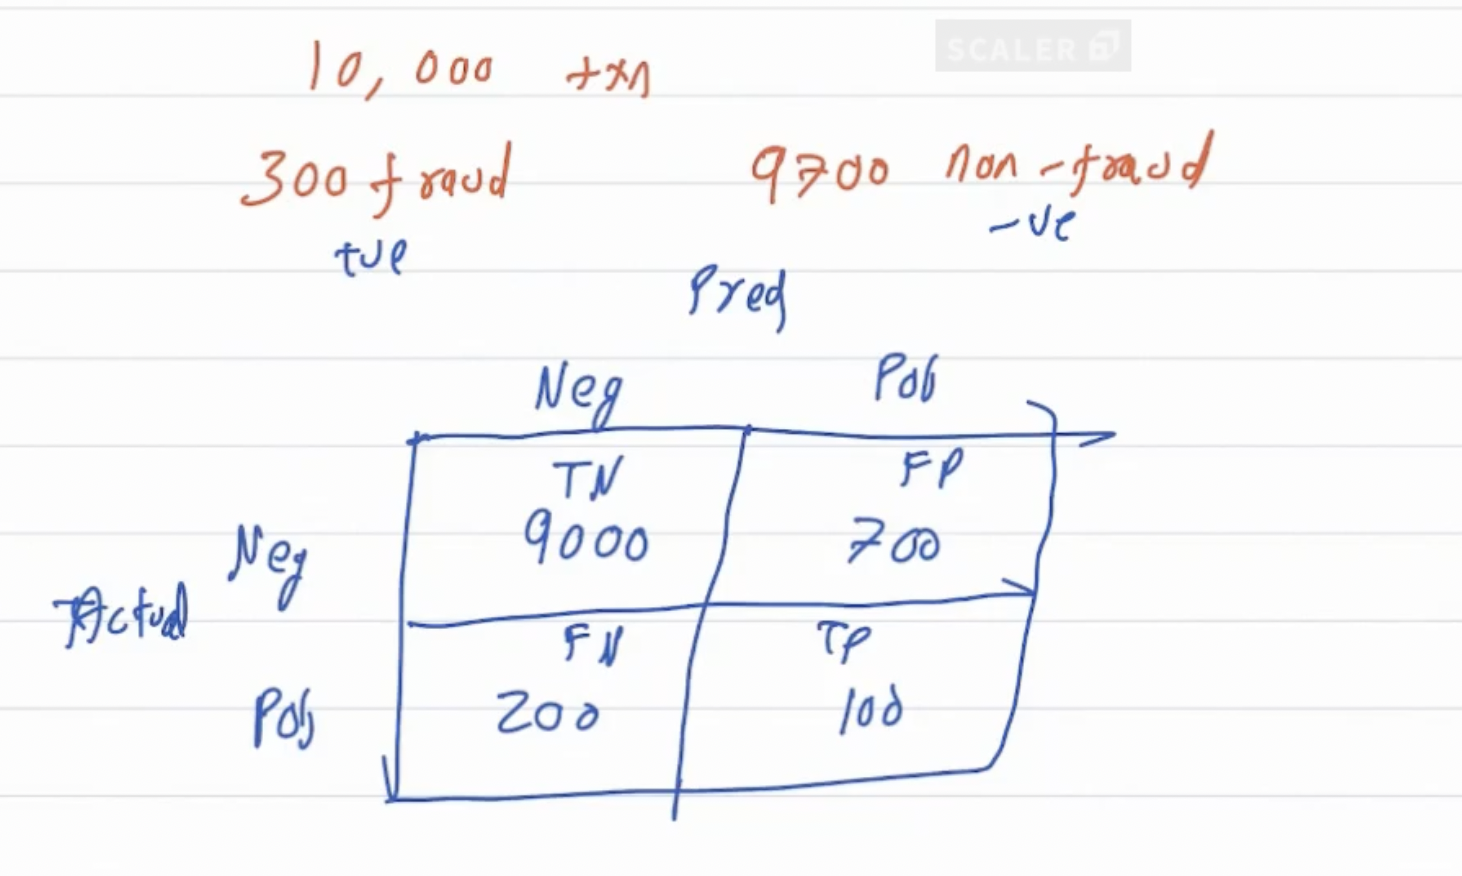

## Solution

#### What will be the accuracy of this model ?
- (TN + TP)/(TN + FP + FN + TP)
- 9100/10000
- 0.91 => 91%

#### what will be the recall for this model ?
- (TP)/(FN+TP)
- 100/(100+200)
- 0.333

#### what will be the precision for this model ?
- (TP)/(FP+TP)
- 100/(700+100)
- 0.126

#### what will be the F1-score for this model ?
- $\frac{2.Precision.Recall}{Precision + Recall}$
- 0.182

#### what will be the FPR for this model ?
- $FPR = \frac{FP}{Actual Negative} = \frac{FP}{TN + FP}$
- 700/9700
- 0.072



In [19]:
from sklearn.metrics import classification_report

In [20]:
print(classification_report(data.y, data.y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     10000
         1.0       0.19      0.55      0.28       100

    accuracy                           0.97     10100
   macro avg       0.59      0.76      0.63     10100
weighted avg       0.99      0.97      0.98     10100



In [22]:
data['y'].value_counts()

,count
y,
0.0,10000
1.0,100


<img src='https://drive.google.com/uc?id=1f5J0tRMFioliW3rQ9JVE9Q9guuqle3bb'>


In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib import pyplot as plt

In [36]:
fpr, tpr, thr = roc_curve(data.y, data.proba)

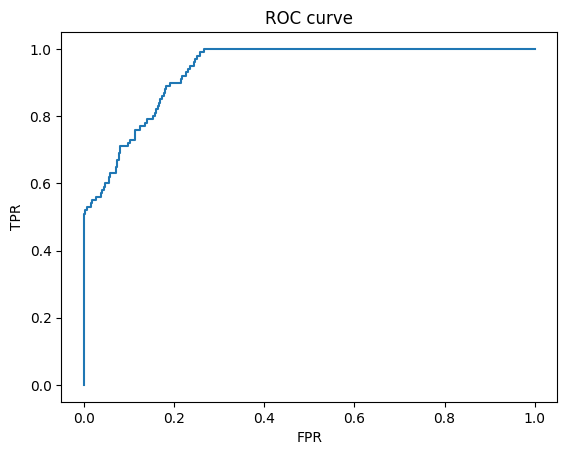

In [37]:
plt.plot(fpr,tpr)
plt.title('ROC curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [41]:
roc_auc_score(data.y, data.proba)

np.float64(0.9377570000000001)

In [42]:
from sklearn.metrics import precision_recall_curve

In [43]:
precision, recall, thresholds = precision_recall_curve(
    data.y,
   data.proba
)

In [49]:
len(recall)

10101

In [48]:
len(precision)

10101

In [47]:
len(thresholds)

10100

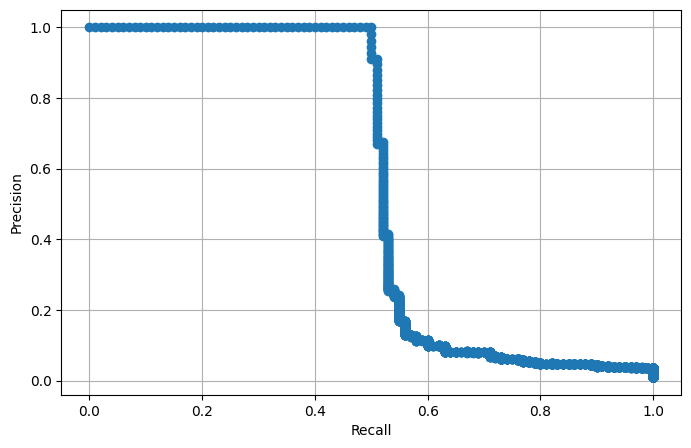

In [45]:
# Plot
plt.figure(figsize=(8,5))
plt.plot(recall, precision, marker='o')
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.grid(True)
plt.show()

## Try evaluating this model end to end

In [50]:
!gdown 1O5fQvg0TsjH5uRlIHNxt-WByTg4SRfwI


Downloading...
From: https://drive.google.com/uc?id=1O5fQvg0TsjH5uRlIHNxt-WByTg4SRfwI
To: /content/pima-indians-diabetes (1).csv
100% 23.8k/23.8k [00:00<00:00, 71.9MB/s]


In [51]:
# read the data into a Pandas DataFrame
import pandas as pd
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
pima = pd.read_csv('pima-indians-diabetes (1).csv', header=1, names=col_names)

# print the first 5 rows of data
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
